In [2]:
from scipy.interpolate import RectBivariateSpline, interp1d
import numpy as np
from cosmopower import cosmopower_NN
import os
import matplotlib.pyplot as plt
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

In [3]:
emu_ranges_all = {
        'Omega_m':      {'p1':0.2899,            'p2':0.3392}, 
        'Omega_b':      {'p1':0.04044,         'p2':0.05686}, 
        'h':            {'p1':0.6375,           'p2':0.731},
        'ns':           {'p1':0.9432,          'p2':0.9862},
        'As':           {'p1':1.5e-09,         'p2':2.7e-09},
        'Omega_nu':     {'p1':0.,              'p2':0.00317},
        'gamma':       {'p1':0.,              'p2':1.},
        'q1':           {'p1':-5.,             'p2':5.},
        'q2':           {'p1':-5.,             'p2':5.},
        'q3':           {'p1':-5.,             'p2':5.},
}

In [5]:
print('initialising Growth Index Parametrisation')
cp_nl_gamma_model = cosmopower_NN(restore=True, 
                        restore_filename='../emulators/react_boost_GammaQsMnu', 
                        )
kh_nl_boost = cp_nl_gamma_model.modes # 0.01..5. h/Mpc 

initialising Growth Index Parametrisation


In [25]:
# sanity check for LCDM limit
def mg_boost_lcdm(q1, q2, q3):
    params_react = {
                'ns'            :  [0.97, 0.97],
                'As'            :  [2.e-09, 2.e-09],
                'H0'            :  [68., 68.],
                'Omega_b'       :  [0.05, 0.05],
                'Omega_m'       :  [0.35, 0.35],  # fixed to LCDM value
                'Omega_nu'      :  [0., 0.],
                'gamma'        :  [0.55, 0.55],  # fixed to LCDM value
                'q1'            :  [q1, q1],
                'q2'            :  [q2, q2],
                'q3'            :  [q3, q3],
                'z'             :  [0., 1.]}

    mg_boost_lcdm = cp_nl_gamma_model.predictions_np(params_react) 
    return mg_boost_lcdm


/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_99893/1334186219.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(title='vary $q_'+str(i+1)+'$', loc='lower left', frameon=False, title_fontsize=20)


Text(0, 0.5, 'boost in $\\Lambda$CDM limit')

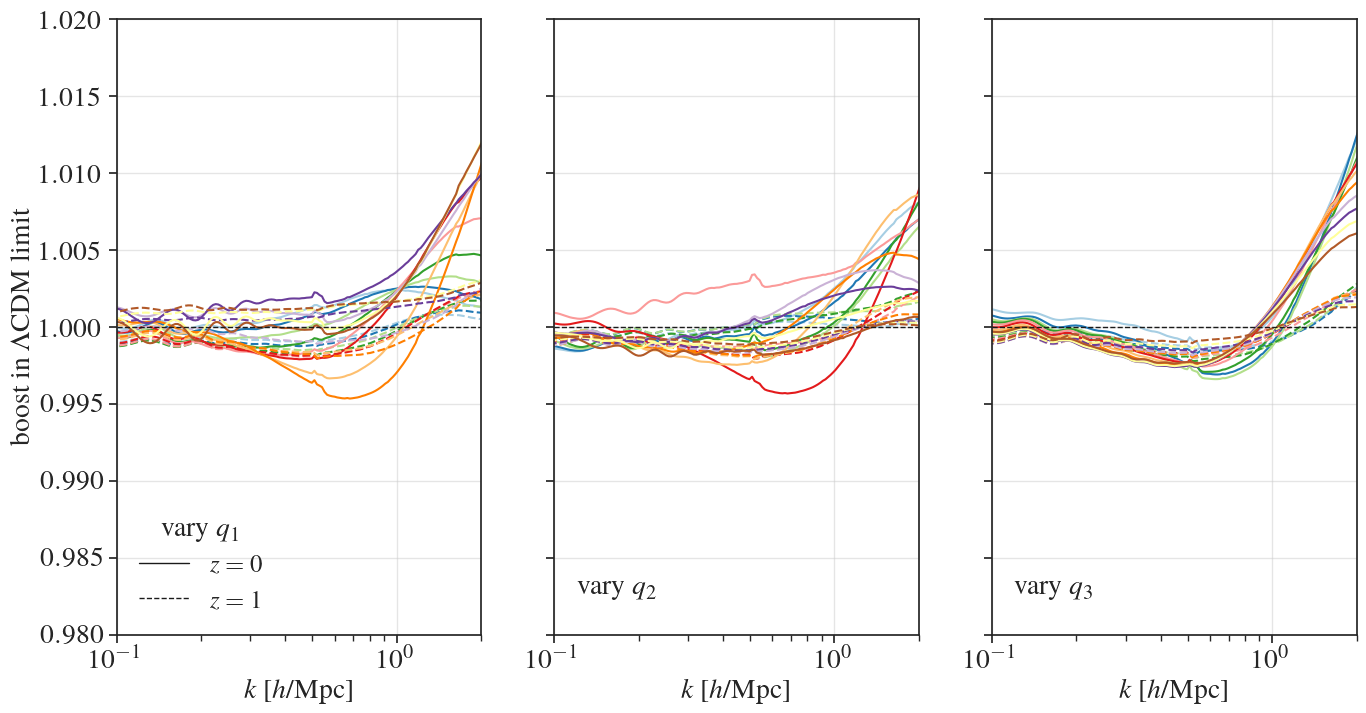

In [47]:
colors = sns.color_palette("Paired")
q_arr = np.linspace(-3, 3, 12)
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w', sharex=True, sharey=True)
for j in range(len(q_arr)):    
    boost = mg_boost_lcdm(q_arr[j], 0., 0.)
    ax[0].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[0].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost_lcdm(0., q_arr[j], 0.)
    ax[1].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[1].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost_lcdm(0., 0., q_arr[j])
    ax[2].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[2].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')
ax[0].axhline(y=0.5, color='k', linestyle='-', linewidth=1, label="$z=0$")    
ax[0].axhline(y=0.5, color='k', linestyle='--', linewidth=1, label="$z=1$")    
for i in range(3):    
    ax[i].legend(title='vary $q_'+str(i+1)+'$', loc='lower left', frameon=False, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    ax[i].grid(alpha=0.5)
    ax[i].grid(alpha=0.5)
    ax[i].set_ylim(0.98, 1.02)    
    ax[i].set_xlim(0.1, 2.)    
    ax[i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("boost in $\\Lambda$CDM limit")

In [48]:
def mg_boost(gamma, q1, q2, q3):
    params_react = {
                'ns'            :  [0.97, 0.97],
                'As'            :  [2.e-09, 2.e-09],
                'H0'            :  [68., 68.],
                'Omega_b'       :  [0.05, 0.05],
                'Omega_m'       :  [0.35, 0.35],  
                'Omega_nu'      :  [0., 0.],
                'gamma'        :  [gamma, gamma],  
                'q1'            :  [q1, q1],
                'q2'            :  [q2, q2],
                'q3'            :  [q3, q3],
                'z'             :  [0., 1.]}

    mg_boost_lcdm = cp_nl_gamma_model.predictions_np(params_react) 
    return mg_boost_lcdm

/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_99893/510889331.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(title='vary $q_'+str(i+1)+'$', loc='upper left', frameon=False, title_fontsize=20)


Text(0, 0.5, 'boost for $\\gamma=0.4$')

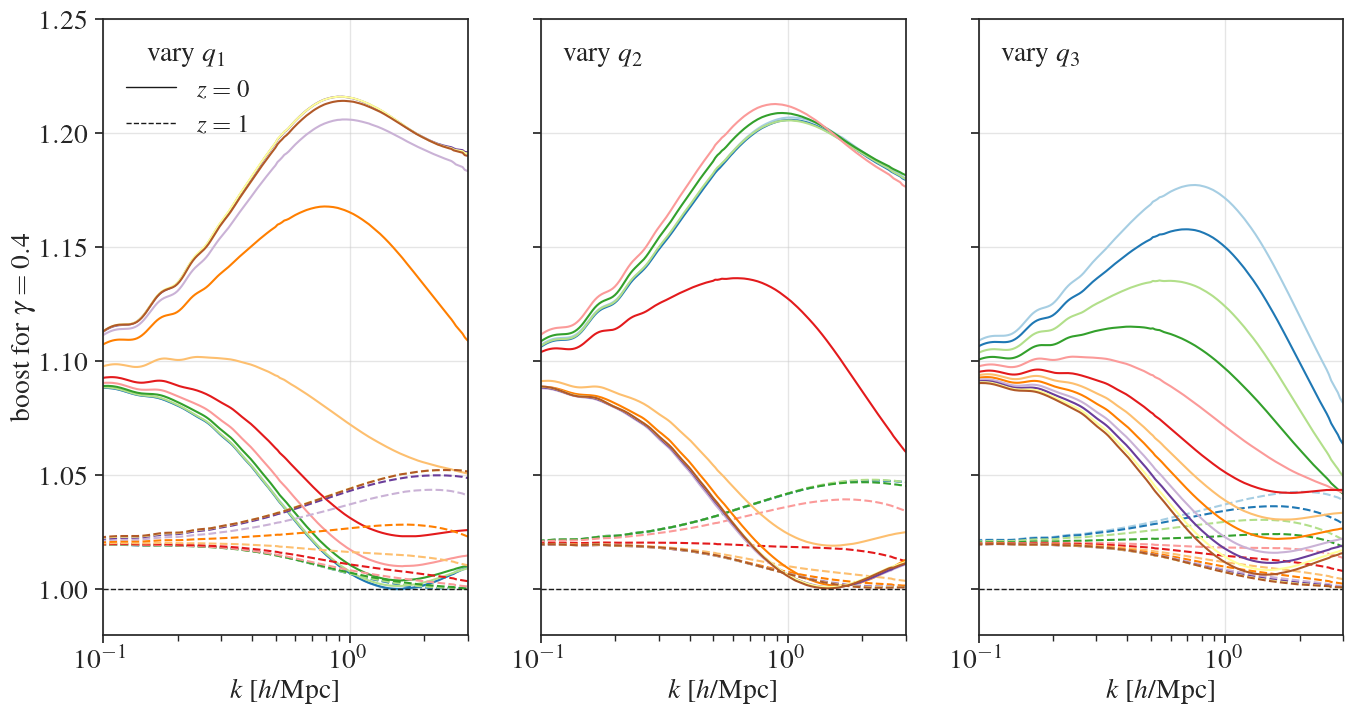

In [52]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w', sharex=True, sharey=True)
for j in range(len(q_arr)):    
    boost = mg_boost(0.4, q_arr[j], 0., 0.)
    ax[0].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[0].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost(0.4, 0., q_arr[j], 0.)
    ax[1].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[1].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost(0.4, 0., 0., q_arr[j])
    ax[2].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[2].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')
ax[0].axhline(y=0.5, color='k', linestyle='-', linewidth=1, label="$z=0$")    
ax[0].axhline(y=0.5, color='k', linestyle='--', linewidth=1, label="$z=1$")    
for i in range(3):    
    ax[i].legend(title='vary $q_'+str(i+1)+'$', loc='upper left', frameon=False, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    ax[i].grid(alpha=0.5)
    ax[i].grid(alpha=0.5)
    ax[i].set_ylim(0.98, 1.25)    
    ax[i].set_xlim(0.1, 3.)    
    ax[i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("boost for $\gamma=0.4$")